# Time-Delay Filters

In [1]:
import jax
import jax.numpy as jnp

import matplotlib.pylab as plt

import WDM
from WDM.code.discrete_wavelet_transform import WDM

In [2]:
dt = 1.0

Nt = 256
Nf = 16
N = Nt*Nf

wdm = WDM.WDM_transform(dt=dt, Nf=Nf, N=N, q=8, calc_m0=True)

wdm.build_time_delay_filter_interpolants(25, 10)

print(wdm)

WDM_transform(Nf=16, N=4096, q=8, d=4, A_frac=0.25, calc_m0=True)
self.Nt = 256 time cells
self.Nf = 16 frequency cells
self.dT = 16.0 time resolution
self.dF = 0.03125 frequency resolution
self.dt = 1.0 time series cadence
self.df = 0.000244140625 time series fft frequency resolution
self.K = 256 window length


In [3]:
import time

l = jnp.array([-2,-1,0,1,2])
delta = jnp.linspace(-105*wdm.dT, 15*wdm.dT, 1000)

t0 = time.time()
T = wdm.time_delay_filter_Tl(l, delta)
print(T[0,0])
t1 = time.time()
print(t1-t0)

t0 = time.time()
T = wdm.time_delay_filter_Tl(l, delta)
print(T[0,0])
t1 = time.time()
print(t1-t0)

[0.]
3.8611960411071777
[0.]
0.003648042678833008


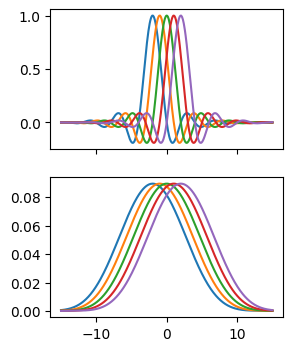

In [4]:
fig, axes = plt.subplots(nrows=2, figsize=(3, 4), sharex=True)

for l in [-2,-1,0,1,2]:
    l = jnp.array([l])
    delta  = jnp.linspace(-15*wdm.dT, 15*wdm.dT, 1000)

    Tl = wdm.time_delay_filter_Tl(l, delta)[0]
    Tprimel = wdm.time_delay_filter_Tprimel(l, delta)[0]
    
    axes[0].plot(delta/wdm.dT, Tl)
    axes[1].plot(delta/wdm.dT, Tprimel)
plt.show()

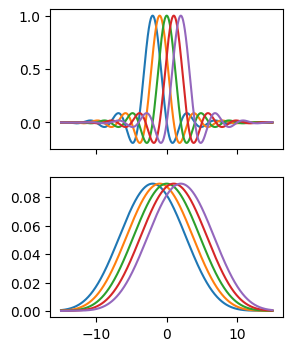

In [5]:
from WDM.code.time_delay_filters.filters import time_delay_filter_Tl, time_delay_filter_Tprimel

fig, axes = plt.subplots(nrows=2, figsize=(3, 4), sharex=True)
for l in range(-2, 3):
    l = jnp.array([l])
    delta  = jnp.linspace(-15*wdm.dT, 15*wdm.dT, 1000)

    Tl = jnp.array([time_delay_filter_Tl(l, d, wdm.freqs, wdm.window_FD, wdm.dT, wdm.df) for d in delta])
    Tprimel = jnp.array([time_delay_filter_Tprimel(l, d, wdm.freqs, wdm.window_FD, wdm.dT, wdm.dF, wdm.N, wdm.df) for d in delta])

    axes[0].plot(delta/wdm.dT, Tl)
    axes[1].plot(delta/wdm.dT, Tprimel)
plt.show()

In [6]:
jnp.divmod(0.1, 1.)

(Array(0., dtype=float64), Array(0.1, dtype=float64, weak_type=True))